<hr style="border: none; height: 3px; background-color: #333;" />

# Project Information

**By:** Samuel Ajeboriogbon *(Popularly known as **SBM Nucopia**)*

**Platform:** __[GitHub](http://github.com/sbmanalyst994)__ | __[LinkedIn](https://www.linkedin.com/in/ajeboriogbon-samuel)__

**Dataset:** Heart Disease Dataset *(Kaggle)*

---

**Project Overview**

This project aims to leverage patient health indicators obtained from a Kaggle dataset *(including features like age, cholesterol, resting blood pressure, max heart rate, and chest pain type)* to predict the likelihood of heart disease. Given that early detection is crucial for improving patient outcomes, this initiative will use data-driven classification techniques to identify key risk factors and develop a robust predictive tool.

---

**Goal**

The Goal of this Project is to establish an accurate predictive model capable of assisting healthcare professionals in identifying high-risk individuals for heart disease, thereby enabling timely medical intervention and supporting better prevention strategies.

---

**Objectives**

The specific Objectives required to achieve the goal are:
- **Exploratory Data Analysis (EDA):** Perform a comprehensive EDA to analyze the patient data, visualize distributions, and identify key health factors that influence the presence or absence of heart disease.
- **Model Development:** Build and train multiple machine learning classification algorithms to predict the target variable *(Presence of Disease / Absence of Disease).*
- **Model Selection:** Evaluate and compare the performance of the implemented algorithms to identify the most suitable and accurate predictive model for heart disease risk classification.

---

### **About the Dataset**

This dataset contains 13 features related to Heart Disease.

### Attribute Information

1. `AGE` → Age
2. `SEX` → 0 = Female, 1 = Male
3. `CP` → Chest pain type
4. `TRESTBPS` → Resting blood pressure *(in mm Hg on admission to the hospital)*
5. `CHOL` → Serum cholesterol *(mg/dl)*
6. `FBS` → Fasting blood sugar > 120 mg/dl *(0 = False, 1 = True)*
7. `RESTECG` → Resting electrocardiographic results
8. `THALACH` → Maximum heart rate achieved
9. `EXANG` → Exercise induced angina *(0 = No, 1 = Yes)*
10. `OLDPEAK` → ST depression induced by exercise relative to rest
11. `SLOPE` → Slope of the peak exercise ST segment
12. `CA` → Number of major vessels *(0–3)* colored by fluoroscopy
13. `THAL` → Thalassemia type *(0 = Normal || 1 = Fixed defect || 2 = Reversible defect)*
14. `TARGET` → 0 = Absence of Disease, 1 = Presence of Disease

<hr style="border: none; height: 3px; background-color: #333;" />

# Data Importation, Cleaning and Verification

In [1]:

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns
sns.set_theme(style='ticks', font_scale=1.1, font='Times New Roman')


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape

(1025, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
# Check for duplicates if any exists

df.duplicated().sum()

np.int64(723)

In [7]:
# View Duplicates

duplicate = df[df.duplicated()]

duplicate

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [8]:
# Remove Duplicates

df.drop_duplicates(inplace=True)

df.shape

(302, 14)

In [9]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0




<hr style="border: none; height: 3px; background-color: #333;" />



# Exploratory Data Analysis (EDA)

In [10]:
# Dataset summary

df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [11]:
# Update Dataset Summary with Skewness, Kurtosis and Range

stats = df.describe().T

stats['Skew'] = df.skew()
stats['Kurt'] = df.kurt()
stats['Range'] = df.max() - df.min()

stats

,count,mean,std,min,25%,50%,75%,max,Skew,Kurt,Range
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0,-0.203743,-0.527512,48.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0,-0.786120,-1.391273,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0,0.493022,-1.183729,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0,0.716541,0.922996,106.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0,1.147332,4.542591,438.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0,1.981201,1.937947,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0,0.169467,-1.359464,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0,-0.532671,-0.062186,131.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0,0.737281,-1.466170,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2,1.266173,1.567876,6.2


In [12]:
# Selecting Categorical variables for distribution check

d = stats[stats['max'] <= 4]

d.drop('target', inplace=True)
d1 = list(d.index)
D = {
    d1[0]: 'Sex',
    d1[1]: 'Chest Pain type',
    d1[2]: 'Fasting Blood Sugar',
    d1[3]: 'Resting EC results',
    d1[4]: 'Exercise-induced angina',
    d1[5]: 'Slope of Peak Exercise',
    d1[6]: 'Vessels colored by fluoroscopy',
    d1[7]: 'Thalassemia type'
}


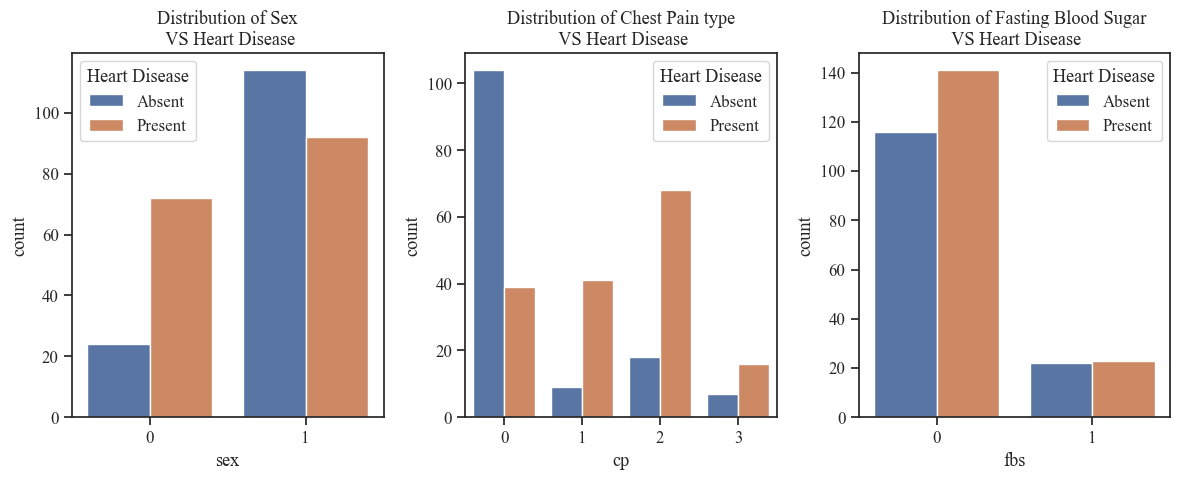

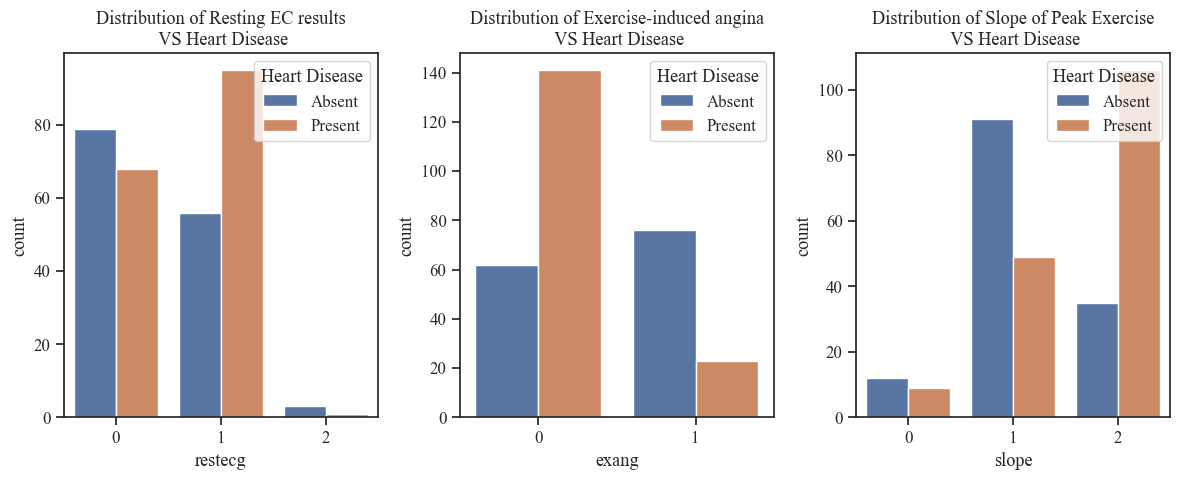

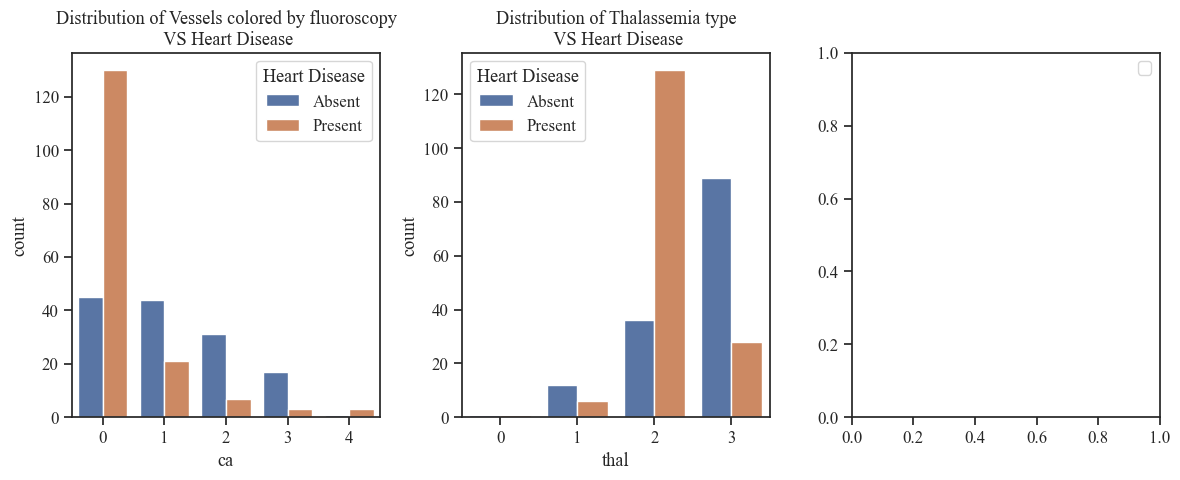

In [13]:
i = 0
fig, axes = plt.subplots(1,3, figsize=(12,5))
for col, name in D.items():
    axes[i].set_title(f'Distribution of {name}\n VS Heart Disease')
    sns.countplot(data=df, x=df[col], ax=axes[i], hue='target')
    plt.tight_layout()
    axes[i].legend(title='Heart Disease', labels=['Absent', 'Present'])

    if i <= 1:
        i += 1
    else:
        i=0
        fig, axes = plt.subplots(1,3, figsize=(12,5))

plt.legend()

Text(0.5, 1.0, 'Age Distribution Plot')

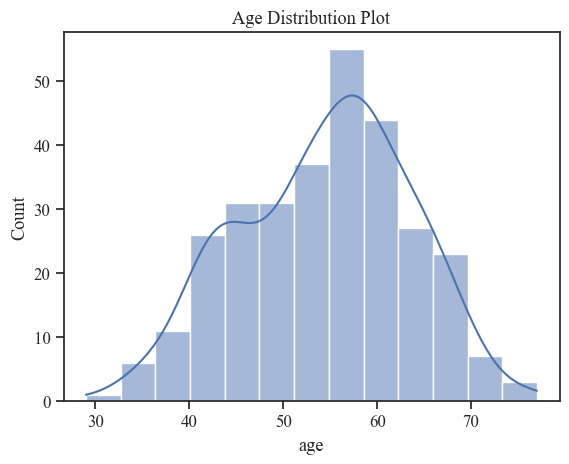

In [14]:
# Age Distribution Plot

sns.histplot(df['age'], kde=True)
plt.title('Age Distribution Plot')

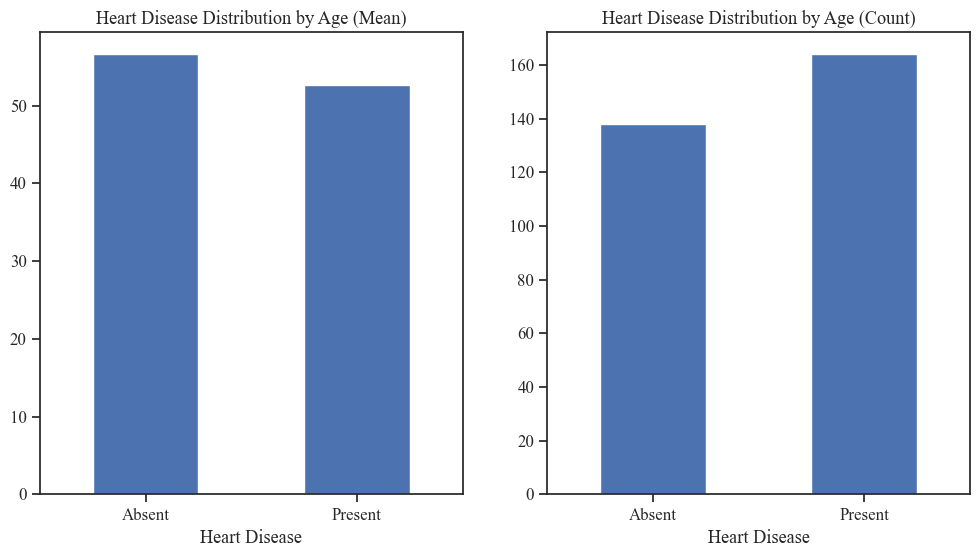

In [15]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

tar_by_age_mean = df.groupby('target')['age'].mean().plot(kind='bar',
                                                    title='Heart Disease Distribution by Age (Mean)',
                                                    xlabel = 'Heart Disease', ax=ax[0])

tar_by_age_count = df.groupby('target')['age'].agg('size').plot(kind='bar',
                                                    title='Heart Disease Distribution by Age (Count)',
                                                    xlabel = 'Heart Disease', ax=ax[1])

ax[0].set_xticks([0,1], ['Absent', 'Present'], rotation=0)
ax[1].set_xticks([0,1], ['Absent', 'Present'], rotation=0)


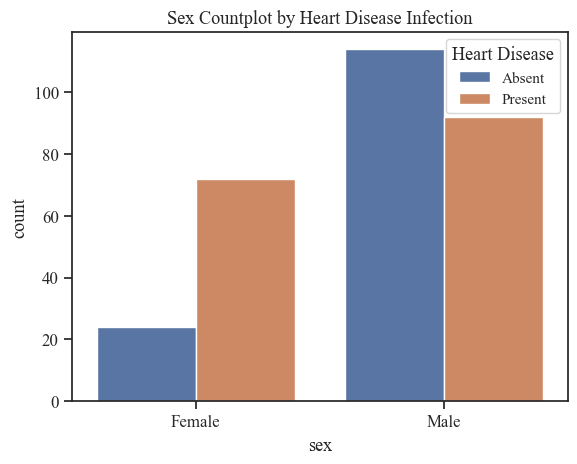

In [16]:
sns.countplot(data=df, x=df['sex'], hue='target')

plt.xticks([0, 1], ['Female', 'Male'])
plt.title('Sex Countplot by Heart Disease Infection')
plt.legend(['Absent', 'Present'], title='Heart Disease', fontsize='small')

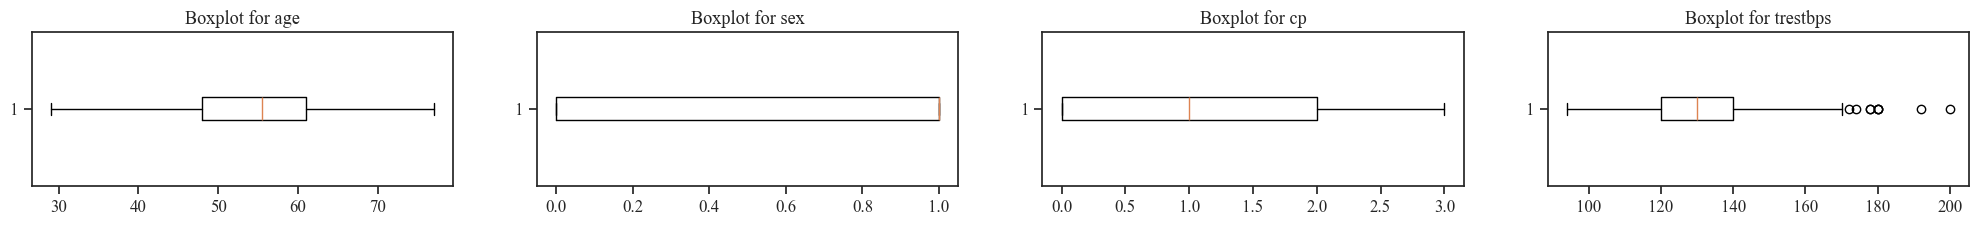

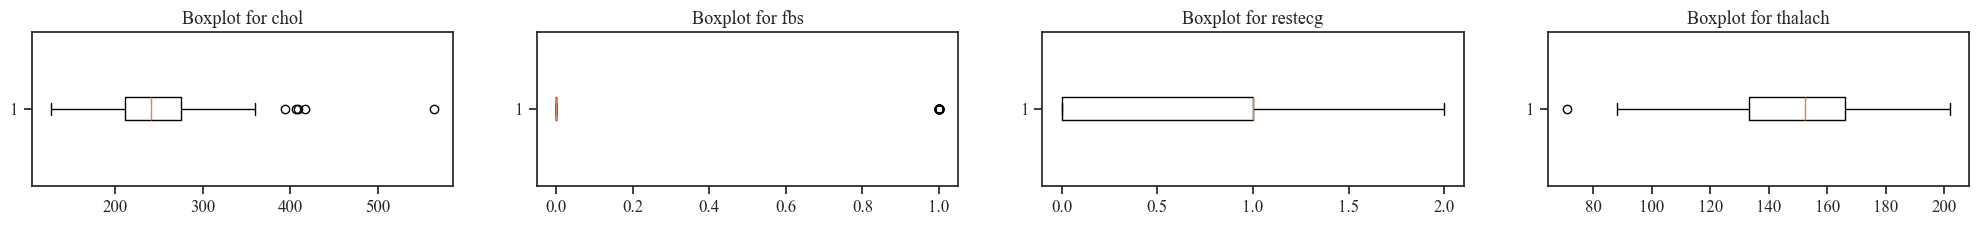

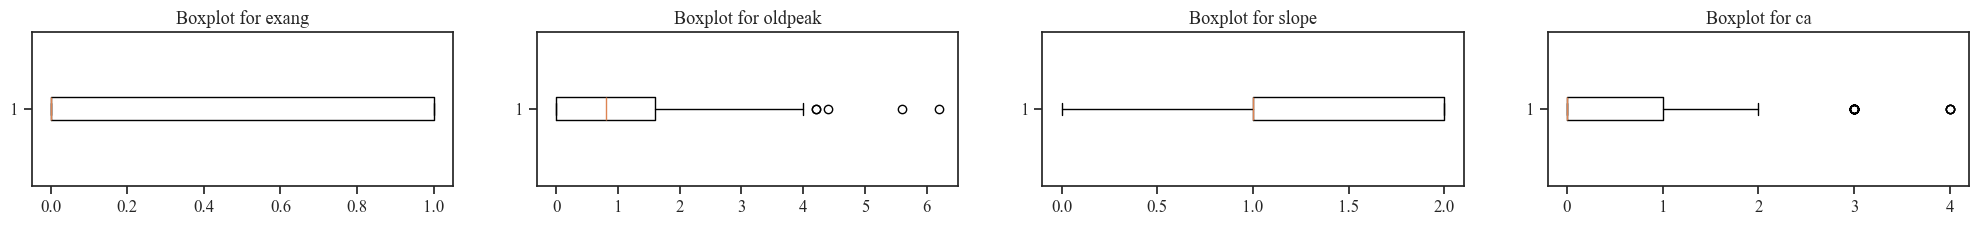

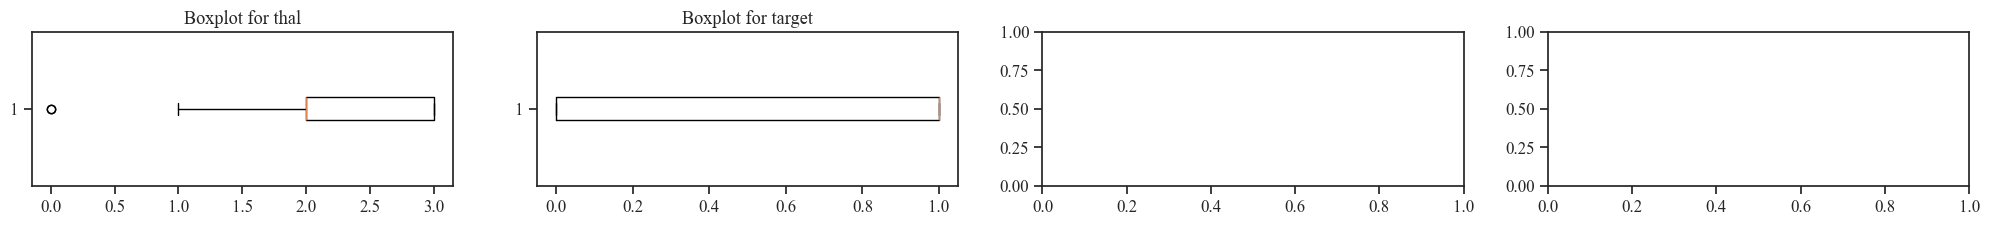

In [17]:
# Check for Outliers via Boxplot

i = 0
fig, ax = plt.subplots(1,4, figsize=(25,2))
for col in df.columns:
    ax[i].boxplot(df[col], vert=False)
    ax[i].set_title(f'Boxplot for {col}')
    if i <= 2:
        i += 1
    else:
        i = 0
        fig, ax = plt.subplots(1,4, figsize=(25,2))

In [18]:
outlier_col = []

for col in df.columns:
    if df[col].nunique() >= 10:
        outlier_col.append(col)

outlier_col

['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

<Axes: xlabel='trestbps', ylabel='Count'>

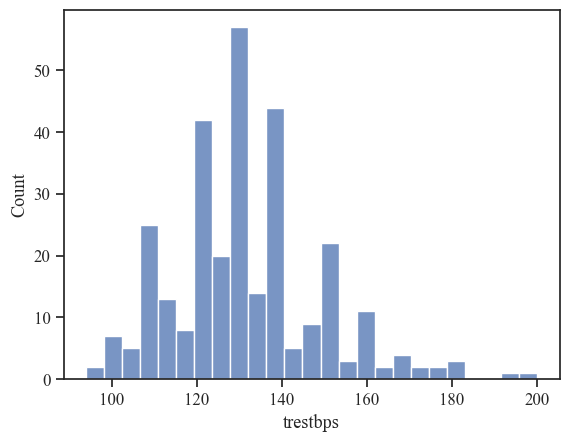

In [19]:
sns.histplot(df['trestbps'], bins=25)

<Axes: xlabel='oldpeak', ylabel='Count'>

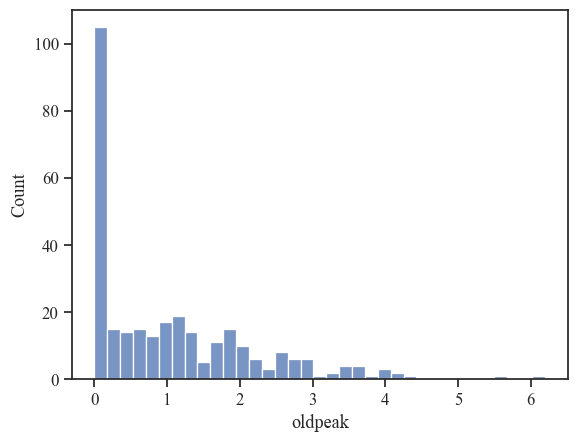

In [20]:
sns.histplot(df['oldpeak'], bins=35)

In [21]:
pd.DataFrame(df['oldpeak'].value_counts()).reset_index().sort_values(by='oldpeak', ascending=False).T

,34,35,30,29,22,37,18,39,23,26,...,24,4,33,2,17,9,20,6,11,0
oldpeak,6.2,5.6,4.4,4.2,4.0,3.8,3.6,3.5,3.4,3.2,...,0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1,0.0
count,1.0,1.0,1.0,2.0,3.0,1.0,4.0,1.0,3.0,2.0,...,3.0,13.0,1.0,14.0,5.0,9.0,3.0,12.0,7.0,98.0


**Outlier Analysis**

After further analysis, Earlier Detected Outliers are kept because they represent genuine high-risk patients, providing critical diagnostic signals that improve the heart disease model's predictive performance.

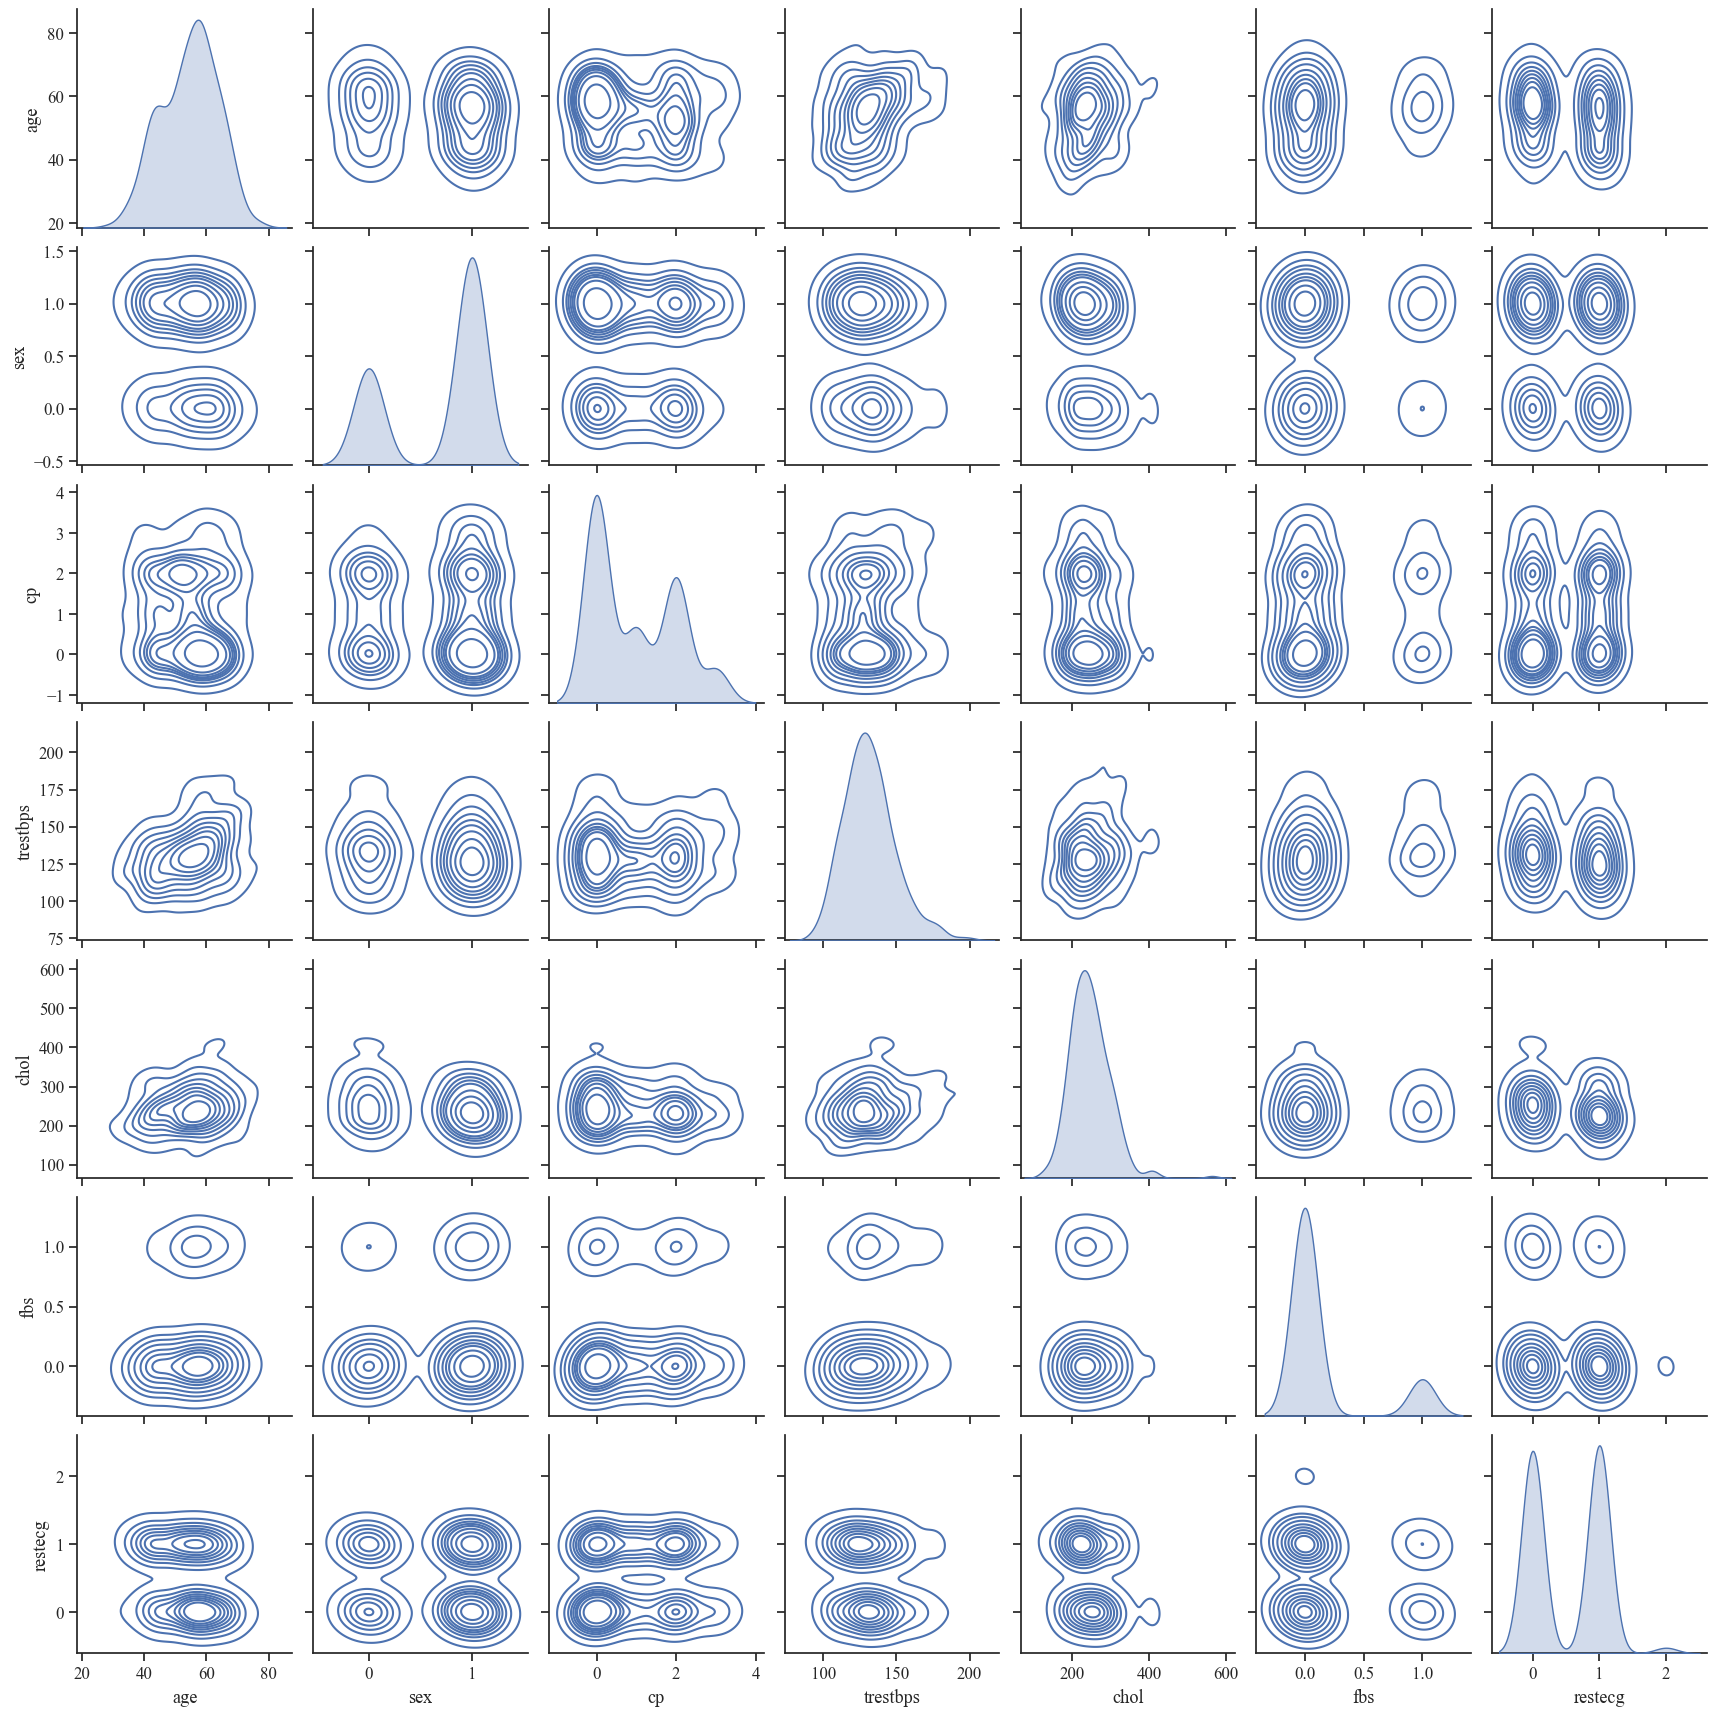

In [22]:
# Pairplot

sns.pairplot(data=df.iloc[:, :7], kind='kde')

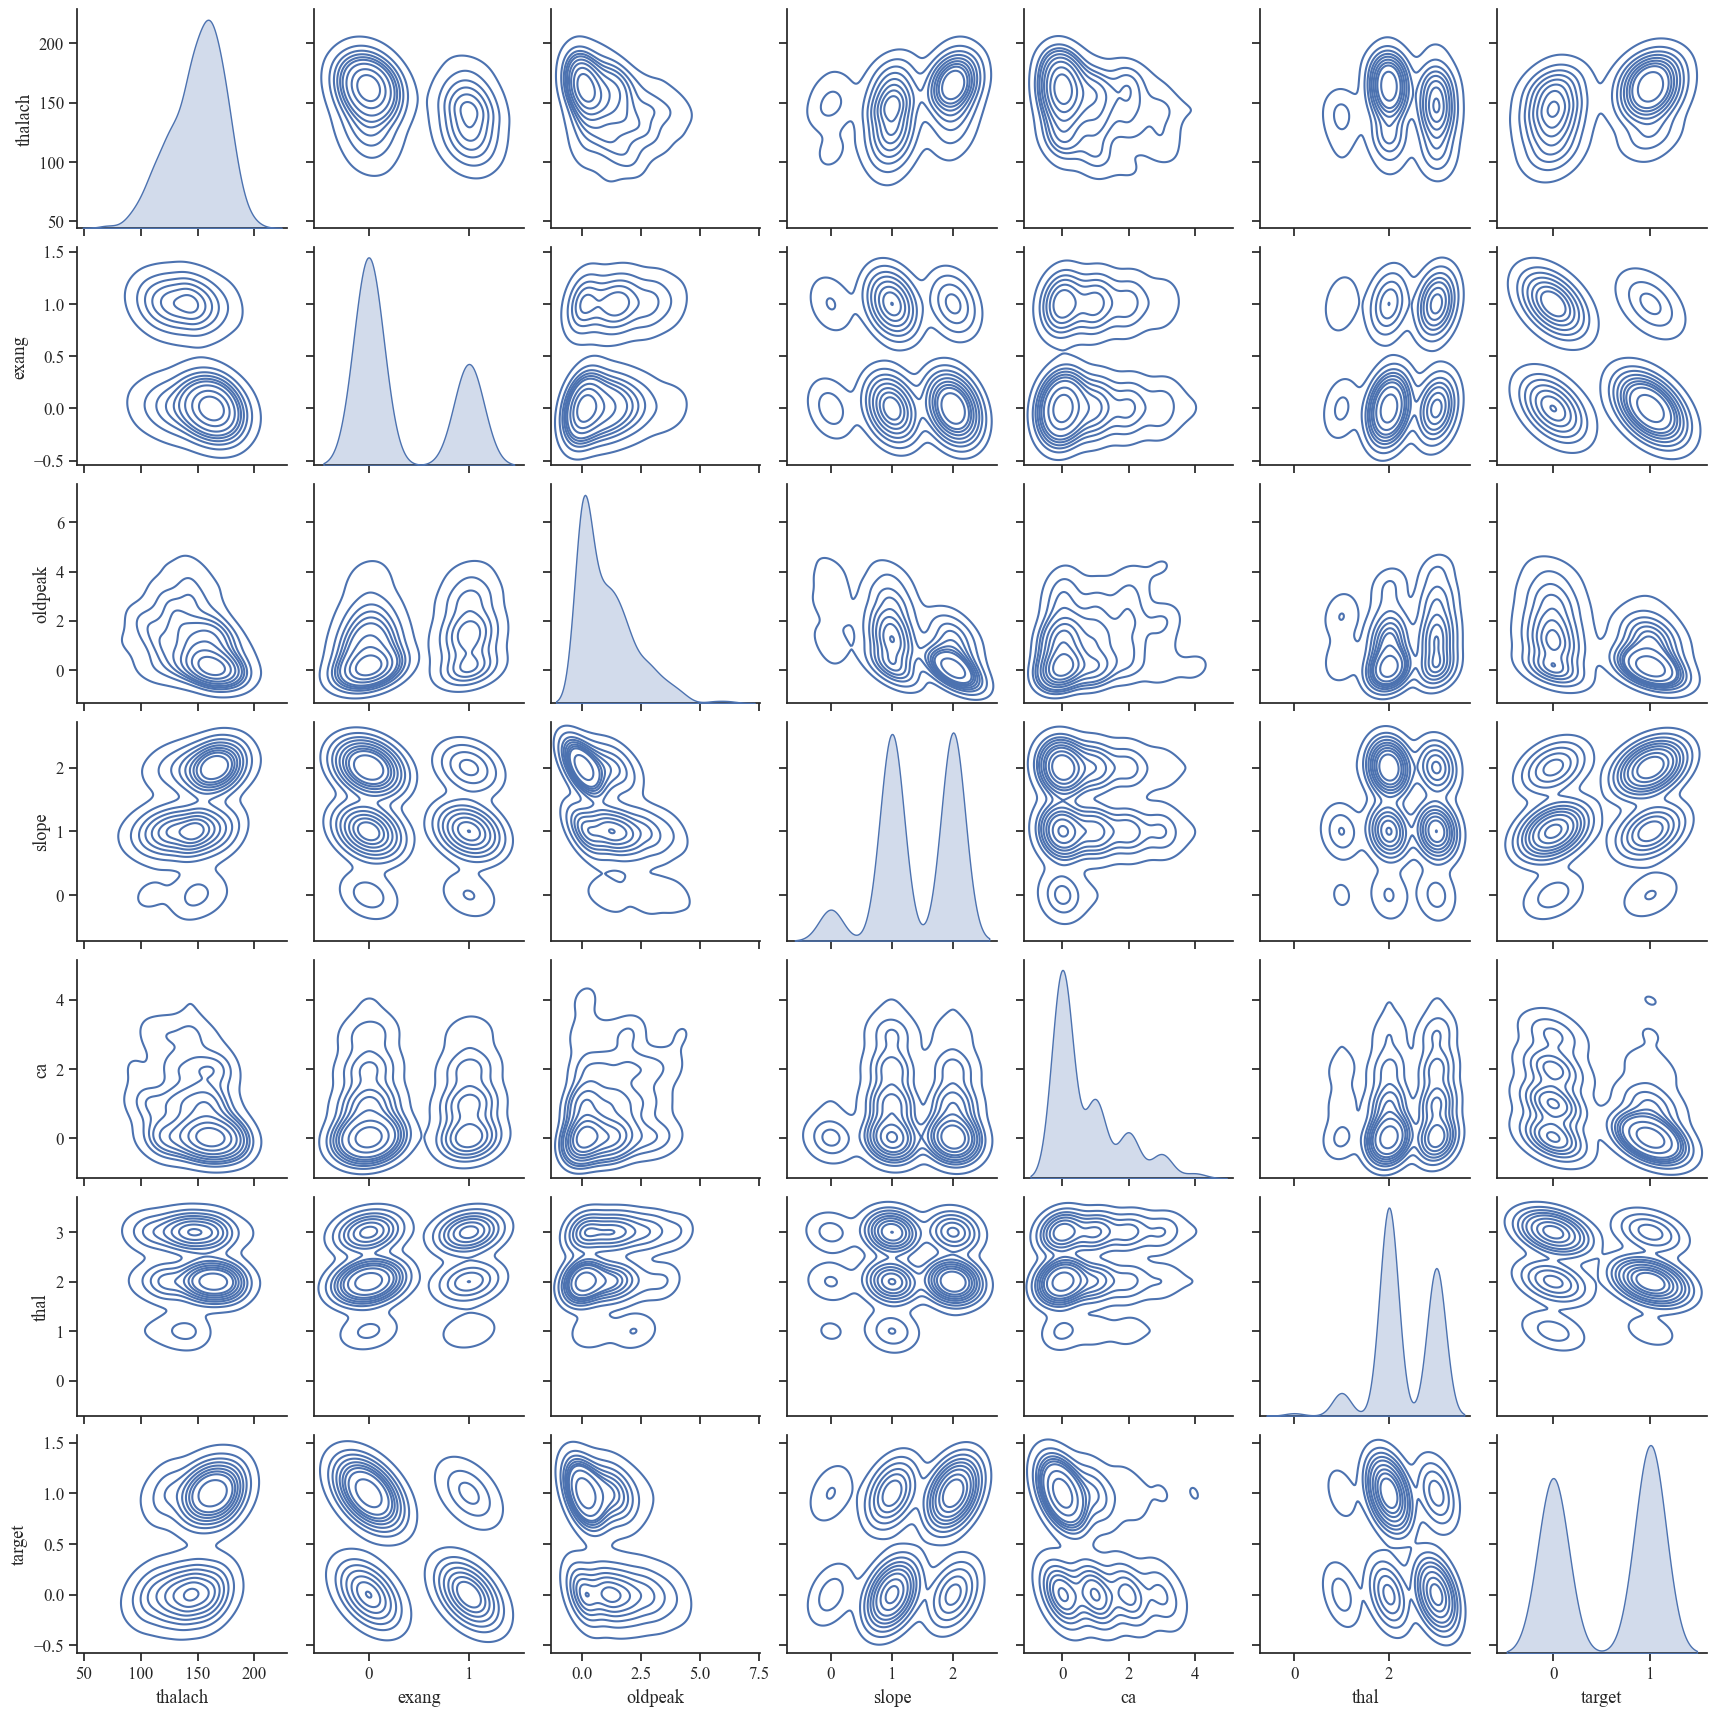

In [23]:
sns.pairplot(df.iloc[:, 7:], kind='kde')

Text(0.5, 1.0, 'Correlation Heatmap of Heart Disease Features')

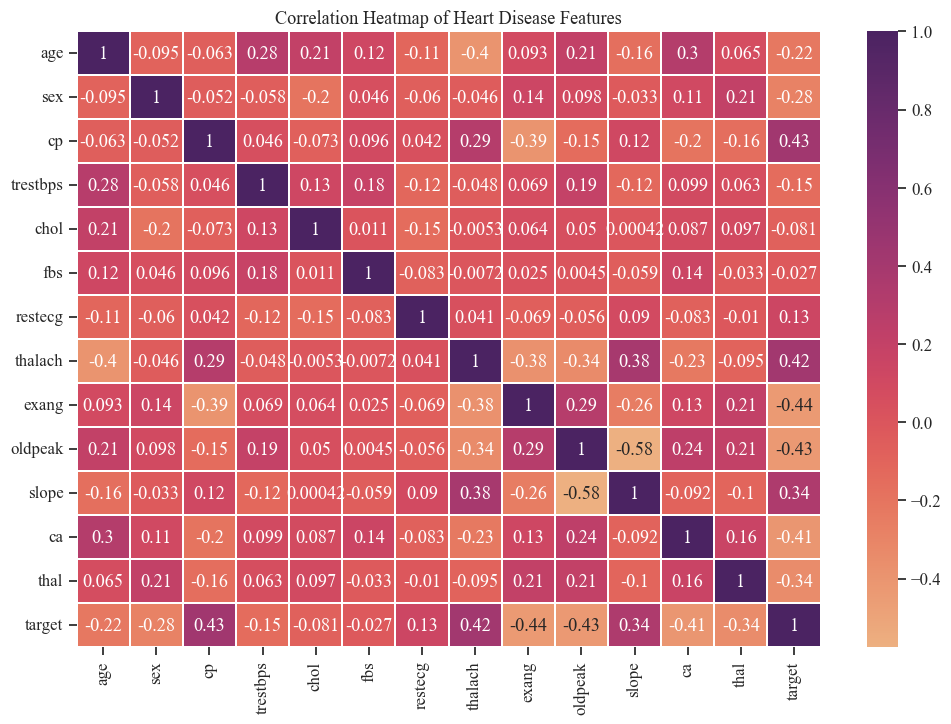

In [24]:
corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='flare', lw=0.15)
plt.xticks(rotation=90)
plt.title('Correlation Heatmap of Heart Disease Features')

**Feature Correlation Analysis:**
This heatmap shows how strongly each feature relates to others using Pearson’s correlation (R).

**Key Insights *(Target vs. Features)***

- **Positively correlated with Heart Disease:**

    - `cp` (Chest Pain Type) → 0.43
    - `exang` (Exercise Induced Angina) → 0.44
    - `oldpeak` (ST Depression) → 0.43
    - `ca` (Major Vessels) → 0.39
    - `thal` (Thalassemia) → 0.34

- **Negatively Correlated with Heart Disease:**

    - `thalach` (Max Heart Rate) → -0.42
    - `slope` (ST Slope) → -0.34
    - `sex` (Gender) → -0.28

- **Weak or No Correlation:**

    - fbs (Fasting Blood Sugar) and chol (Cholesterol) → very weak impact.

**Conclusion:** Chest pain, exercise-related features, and heart rate show the strongest linear relationships with heart disease.

Text(0.5, 1.02, 'Pairwise Relationships among Key Features')

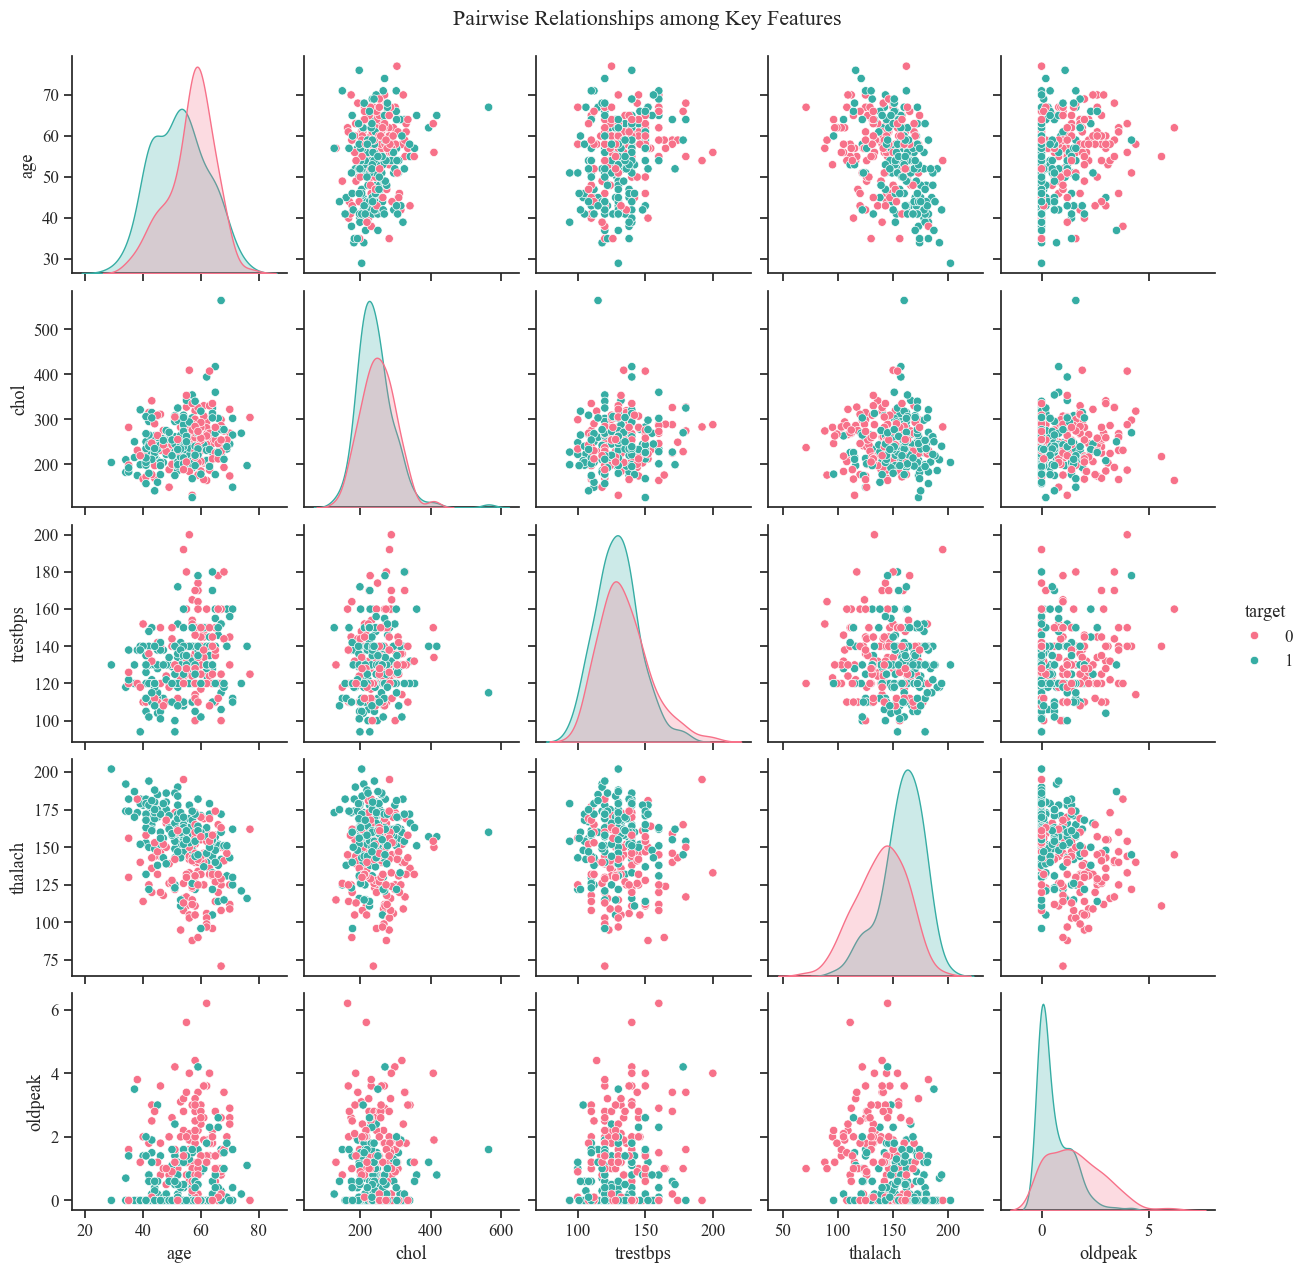

In [25]:
# Check the Pairplot of Selected Features
selected_col = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak', 'target']
sns.pairplot(df[selected_col], hue='target', palette='husl')
plt.suptitle('Pairwise Relationships among Key Features', y=1.02)


<hr style="border: none; height: 3px; background-color: #333;" />

# Model Training

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, make_scorer

In [27]:
data = df.copy()

In [28]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


<hr style="border: none; height: 1.5px; background-color: #333;" />


## Data Spliting and Scaling

In [29]:
X = data.drop('target', axis=1)
y = data['target']

In [30]:
scale = StandardScaler()
X_scaled = scale.fit_transform(X)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=111)

<hr style="border: none; height: 1.5px; background-color: #333;" />

## Testing Mulitple Models

In [32]:
model_list = ['XGBClassifier', 'MLPClassifier', 'RandomForestClassifier', 'DecisionTreeClassifier',
          'GradientBoostingClassifier', 'LogisticRegression', 'RidgeClassifier', 'SVC']
model_func = [XGBClassifier(), MLPClassifier(), RandomForestClassifier(), DecisionTreeClassifier(),
             GradientBoostingClassifier(), LogisticRegression(), RidgeClassifier(), SVC()]
models = dict(zip(model_list, model_func))

results = []
for i,m in models.items():
    model = m
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    result = dict(Model=i, Accuracy = accuracy_score(y_test, pred), f1 = f1_score(y_test, pred),
                 Precision = precision_score(y_test, pred), Recall = recall_score(y_test, pred))
    results.append(result)

pd.DataFrame(results)

,Model,Accuracy,f1,Precision,Recall
0,XGBClassifier,0.803279,0.800000,0.800000,0.800000
1,MLPClassifier,0.819672,0.813559,0.827586,0.800000
2,RandomForestClassifier,0.852459,0.852459,0.838710,0.866667
3,DecisionTreeClassifier,0.737705,0.741935,0.718750,0.766667
4,GradientBoostingClassifier,0.803279,0.806452,0.781250,0.833333
5,LogisticRegression,0.836066,0.843750,0.794118,0.900000
6,RidgeClassifier,0.852459,0.861538,0.800000,0.933333
7,SVC,0.786885,0.779661,0.793103,0.766667


<hr style="border: none; height: 1.5px; background-color: #333;" />


## Hyper-Parameter Tuning to get Best Parameter 

In [33]:
param_grids = {
    'XGBClassifier': {
        'model': XGBClassifier(random_state=111, n_jobs=-1, verbosity=0),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.3],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        }
    },
    'MLPClassifier': {
        'model': MLPClassifier(random_state=111, max_iter=1000),
        'params': {
            'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
            'activation': ['relu', 'tanh'],
            'alpha': [0.0001, 0.001, 0.01],
            'learning_rate_init': [0.001, 0.01],
            'batch_size': [32, 64, 128]
        }
    },
    'RandomForestClassifier': {
        'model': RandomForestClassifier(random_state=111, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        }
    },
    'GradientBoostingClassifier': {
        'model': GradientBoostingClassifier(random_state=111),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 4, 5],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'subsample': [0.8, 1.0]
        }
    },
    'LogisticRegression': {
        'model': LogisticRegression(random_state=111, n_jobs=-1, max_iter=1000),
        'params': {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'penalty': ['l2'],
            'solver': ['lbfgs', 'sag', 'saga']
        }
    },
    'RidgeClassifier': {
        'model': RidgeClassifier(random_state=111),
        'params': {
            'alpha': [0.1, 1.0, 10.0, 100.0],
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg']
        }
    }
}

In [34]:
scoring = {
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score, average='weighted')
}

results_list = []
print("Starting Grid Search with multiple metrics...")

for model_name, mp in param_grids.items():
    print(f"Running GridSearchCV for {model_name}...")
    
    clf = GridSearchCV(mp['model'], mp['params'], cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=111),
                       scoring=scoring, refit='f1', n_jobs=-1, verbose=3, return_train_score=True)
    clf.fit(X_train, y_train)
    
    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='weighted')
    
    results_list.append({
        'Model': model_name, 'CV_F1_Score': clf.best_score_,
        'CV_Accuracy': clf.cv_results_['mean_test_accuracy'][clf.best_index_],
        'Test_Accuracy': test_acc, 'Test_F1': test_f1, 'Best_Params': clf.best_params_
    })



Starting Grid Search with multiple metrics...
Running GridSearchCV for XGBClassifier...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Running GridSearchCV for MLPClassifier...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Running GridSearchCV for RandomForestClassifier...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Running GridSearchCV for GradientBoostingClassifier...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Running GridSearchCV for LogisticRegression...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Running GridSearchCV for RidgeClassifier...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [35]:
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='Test_F1', ascending=False)

print("\n" + "="*120)
print("GRID SEARCH RESULTS (Sorted by Test F1)")
print("="*120)
results_df


GRID SEARCH RESULTS (Sorted by Test F1)


,Model,CV_F1_Score,CV_Accuracy,Test_Accuracy,Test_F1,Best_Params
3,GradientBoostingClassifier,0.795034,0.796854,0.852459,0.852459,"{'learning_rate': 0.01, 'max_depth': 3, 'min_s..."
2,RandomForestClassifier,0.836831,0.838010,0.852459,0.852459,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
4,LogisticRegression,0.836347,0.838180,0.852459,0.851663,"{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}"
0,XGBClassifier,0.807202,0.809184,0.836066,0.836066,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
5,RidgeClassifier,0.831038,0.834014,0.836066,0.834735,"{'alpha': 10.0, 'solver': 'auto'}"
1,MLPClassifier,0.816611,0.817517,0.770492,0.770121,"{'activation': 'tanh', 'alpha': 0.0001, 'batch..."


<hr style="border: none; height: 1.5px; background-color: #333;" />


## Modifying the Better Model *(RandomForest)*

In [ ]:
results_df['Best_Params'].iloc[1]

In [37]:
rf = RandomForestClassifier(max_depth = None, max_features = 'sqrt', min_samples_leaf=4,
                            min_samples_split=2, n_estimators=300, random_state=111)
rf.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=4, n_estimators=300, random_state=111)

In [38]:
rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.87      0.84      0.85        31
           1       0.84      0.87      0.85        30

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



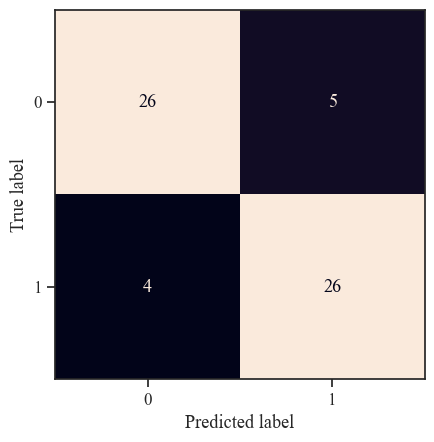

In [39]:
cm = ConfusionMatrixDisplay(confusion_matrix(y_test, rf_pred))

cm.plot(cmap='rocket', colorbar=False)
cm.ax_.grid(visible=False)

<hr style="border: none; height: 1.5px; background-color: #333;" />


## Features Importance

In [47]:
importance = rf.feature_importances_

#Renaming Columns
X = X.rename(columns={
    'age': 'Age',
    'sex': 'Sex',
    'cp': 'Chest Pain Type',
    'trestbps': 'Resting BP',
    'chol': 'Serum Cholesterol',
    'fbs': 'Fasting Blood Sugar',
    'restecg': 'Resting ECG',
    'thalach': 'Max Heart Rate',
    'exang': 'Exercise Angina',
    'oldpeak': 'ST Depression',
    'slope': 'Slope ST Segment',
    'ca': 'Major Vessels',
    'thal': 'Thalassemia'
})

features = X.columns

ft_importance = pd.DataFrame({'Feature':features, 'Importance':importance}).sort_values(by='Importance', ascending=False)

ft_importance

,Feature,Importance
12,Thalassemia,0.170256
2,Chest Pain Type,0.129720
9,ST Depression,0.121443
7,Max Heart Rate,0.108584
11,Major Vessels,0.103718
8,Exercise Angina,0.080626
10,Slope ST Segment,0.074601
0,Age,0.061227
4,Serum Cholesterol,0.053104
3,Resting BP,0.041181


<Axes: xlabel='Importance', ylabel='Feature'>

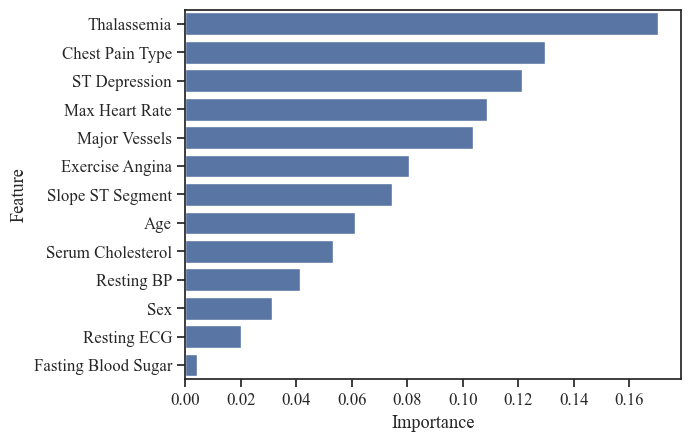

In [48]:
sns.barplot(data=ft_importance, y='Feature', x='Importance', orient='h')

The **Random Forest model** successfully identified the most influential factors for predicting heart disease, providing a clear hierarchy of importance:

* **Thalassemia** is the **most significant predictor**, showing a strong association with the presence of heart disease.
* **Chest Pain Type**, **ST Depression**, **Maximum Heart Rate**, and **Number of Major Vessels** are also critical determinants of heart health.
* **Exercise Angina**, **Slope ST Segment**, **Age**, **Serum Cholesterol**, and **Resting BP** show **moderate importance**, contributing notably to cardiovascular risk assessment.
* Features such as **Fasting Blood Sugar** and **Resting ECG** have **minimal influence** on the prediction outcome.

*These insights suggest that Thalassemia type, Chest pain type, ST Depression, Maximum Heart Rate, and number of Major Vessels are the strongest indicators to prioritize in model interpretation and app input design.*

<hr style="border: none; height: 1.5px; background-color: #333;" />


## Saving Model files for Deployment

In [49]:
import pickle

model_file = "model.pkl"
with open(model_file, 'wb') as file:
    pickle.dump(rf, file)

scale_file = "scaler.pkl"
with open(scale_file, 'wb') as file:
    pickle.dump(scale, file)


<hr style="border: none; height: 1.5px; background-color: #333;" />


## Test Model Here

__[Heart Disease Prediction App](https://www.google.com)__

In [57]:
input_dict = {
    'age': 40,
    'sex': 1,
    'cp': 3,
    'trestbps': 4,
    'chol': 1,
    'fbs': 0,
    'restecg': 4,
    'thalach': 2,
    'exang': 3,
    'oldpeak': 1,
    'slope': 1,
    'ca': 0,
    'thal': 7
}

input_data = pd.DataFrame([input_dict])

# col = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", 
#        "thalach", "exang", "oldpeak", "slope", "ca", "thal"]
input_data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,40,1,3,4,1,0,4,2,3,1,1,0,7
